# 4-1. 인구현황 데이터 분석

`data/인구현황.csv` 데이터를 이용해 지역별 인구 현황을 분석합니다.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import os

# seaborn 스타일을 먼저 적용한 뒤, 한글 폰트를 설정해야
# set_style()이 font.family를 덮어쓰지 않습니다.
sns.set_style('whitegrid')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

# 노트북을 실행하는 위치(VS Code / Jupyter Lab 등)에 따라 현재 작업 디렉토리가
# 달라질 수 있어서, 자주 쓰이는 후보 경로들을 순서대로 확인해 파일을 찾습니다.
candidate_paths = [
    'data/인구현황.csv',
    '../data/인구현황.csv',
    './인구현황.csv',
    '../인구현황.csv',
]
csv_path = next((p for p in candidate_paths if os.path.exists(p)), None)
if csv_path is None:
    raise FileNotFoundError(
        '인구현황.csv를 찾을 수 없습니다. 이 노트북과 같은 위치, 혹은 상위 폴더의 '
        'data 폴더 안에 인구현황.csv 파일이 있는지 확인하거나, candidate_paths에 '
        '실제 경로를 추가해주세요. (현재 작업 디렉토리: {})'.format(os.getcwd())
    )

df = pd.read_csv(csv_path, encoding='utf-8')
df.head()

,행정기관코드,행정기관,총인구수,세대수,세대당 인구,남자 인구수,여자 인구수,남여 비율
0,1000000000,전국,51217221,24118928,2.12,25498324,25718897,0.99
1,1100000000,서울특별시,9331828,4482063,2.08,4505355,4826473,0.93
2,2600000000,부산광역시,3266598,1570403,2.08,1589912,1676686,0.95
3,2700000000,대구광역시,2363629,1104130,2.14,1159601,1204028,0.96
4,2800000000,인천광역시,3021010,1373827,2.20,1509243,1511767,1.00


In [3]:
# '전국' 행은 합계 데이터이므로 지역별 분석에서는 제외
df_region = df[df['행정기관'] != '전국']
df_region.head()

,행정기관코드,행정기관,총인구수,세대수,세대당 인구,남자 인구수,여자 인구수,남여 비율
1,1100000000,서울특별시,9331828,4482063,2.08,4505355,4826473,0.93
2,2600000000,부산광역시,3266598,1570403,2.08,1589912,1676686,0.95
3,2700000000,대구광역시,2363629,1104130,2.14,1159601,1204028,0.96
4,2800000000,인천광역시,3021010,1373827,2.20,1509243,1511767,1.00
5,2900000000,광주광역시,1408422,658075,2.14,695224,713198,0.97


## 1. 지역별 총인구수 Top5

In [4]:
top5_total = df_region[['행정기관', '총인구수']].sort_values(by='총인구수', ascending=False).head(5)
top5_total

,행정기관,총인구수
9,경기도,13694685
1,서울특별시,9331828
2,부산광역시,3266598
16,경상남도,3228380
4,인천광역시,3021010


### 1-1. 지역별 총인구수 plot

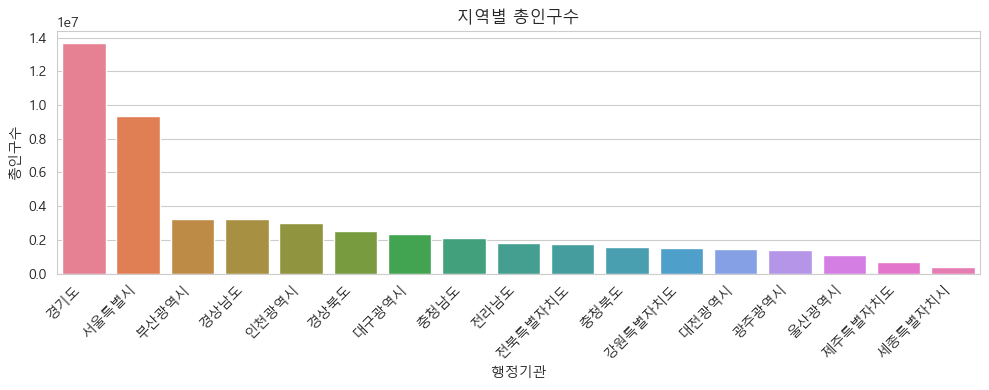

In [5]:
df_total_sorted = df_region.sort_values(by='총인구수', ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(data=df_total_sorted, x='행정기관', y='총인구수',
            hue='행정기관', palette='husl', legend=False)
plt.title('지역별 총인구수')
plt.xlabel('행정기관')
plt.ylabel('총인구수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. 세대당 인구수 높은 지역 Top5

In [6]:
top5_per_house = (df_region[['행정기관', '세대당 인구']]
                   .sort_values(by='세대당 인구', ascending=False)
                   .head(5)
                   .reset_index(drop=True))
top5_per_house

,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14


### 2-1. 지역별 세대당 인구 Plot

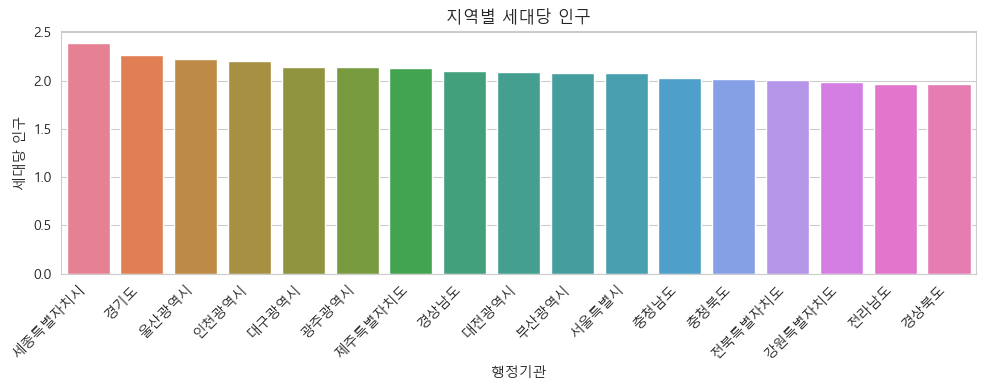

In [7]:
df_house_sorted = df_region.sort_values(by='세대당 인구', ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(data=df_house_sorted, x='행정기관', y='세대당 인구',
            hue='행정기관', palette='husl', legend=False)
plt.title('지역별 세대당 인구')
plt.xlabel('행정기관')
plt.ylabel('세대당 인구')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. 남녀 비율 분석

In [8]:
gender_ratio = (df_region[['행정기관', '남여 비율']]
                .sort_values(by='남여 비율', ascending=False)
                .reset_index(drop=True))
gender_ratio

,행정기관,남여 비율
0,울산광역시,1.06
1,충청남도,1.05
2,충청북도,1.04
3,경상남도,1.02
4,경상북도,1.02
5,전라남도,1.02
6,경기도,1.01
7,강원특별자치도,1.01
8,제주특별자치도,1.00
9,인천광역시,1.00


### 3-1. 남녀 비율 분석 Plot

기준이 되는 빨간선은 `axhline()` 함수를 사용해 그립니다. (남녀 비율이 1.0이면 남녀 인구가 동일함을 의미)

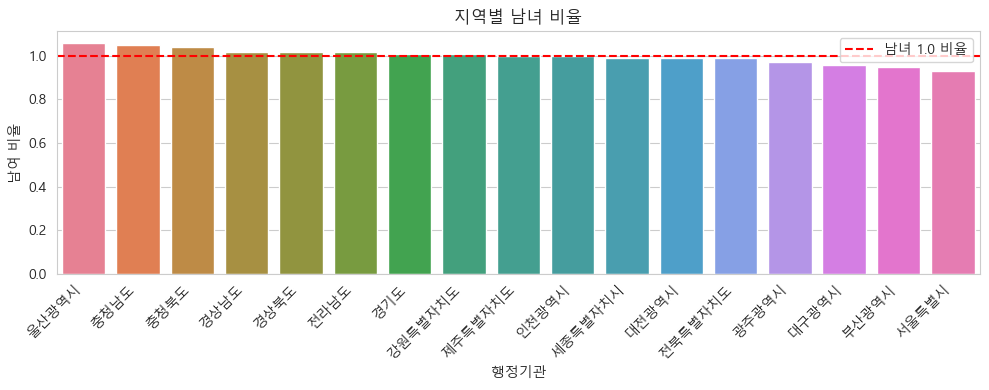

In [9]:
plt.figure(figsize=(10, 4))
sns.barplot(data=gender_ratio, x='행정기관', y='남여 비율',
            hue='행정기관', palette='husl', legend=False)
plt.axhline(y=1.0, color='red', linestyle='--', label='남녀 1.0 비율')
plt.title('지역별 남녀 비율')
plt.xlabel('행정기관')
plt.ylabel('남여 비율')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 4. 남자초과 / 여자초과 분석

In [10]:
def classify_gender(ratio):
    if ratio > 1:
        return '남초'
    elif ratio < 1:
        return '여초'
    else:
        return '동일'

df_region = df_region.copy()
df_region['남초여초'] = df_region['남여 비율'].apply(classify_gender)

gender_excess = df_region[['행정기관', '남여 비율', '남초여초']]
gender_excess

,행정기관,남여 비율,남초여초
1,서울특별시,0.93,여초
2,부산광역시,0.95,여초
3,대구광역시,0.96,여초
4,인천광역시,1.00,동일
5,광주광역시,0.97,여초
6,대전광역시,0.99,여초
7,울산광역시,1.06,남초
8,세종특별자치시,0.99,여초
9,경기도,1.01,남초
10,강원특별자치도,1.01,남초


## 5. 세대당 인구 평균보다 높은 지역

In [11]:
avg_per_house = df_region['세대당 인구'].mean()
print(f'전국 평균 세대당 인구수: {avg_per_house:.2f}')

above_avg = (df_region[df_region['세대당 인구'] > avg_per_house][['행정기관', '세대당 인구']]
             .sort_values(by='세대당 인구', ascending=False)
             .reset_index(drop=True))
above_avg

전국 평균 세대당 인구수: 2.11


,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14
5,광주광역시,2.14
6,제주특별자치도,2.13


### 5-1. 남초 vs 여초 개수 Plot (seaborn countplot) / 지역별 세대수 Plot (seaborn barplot)

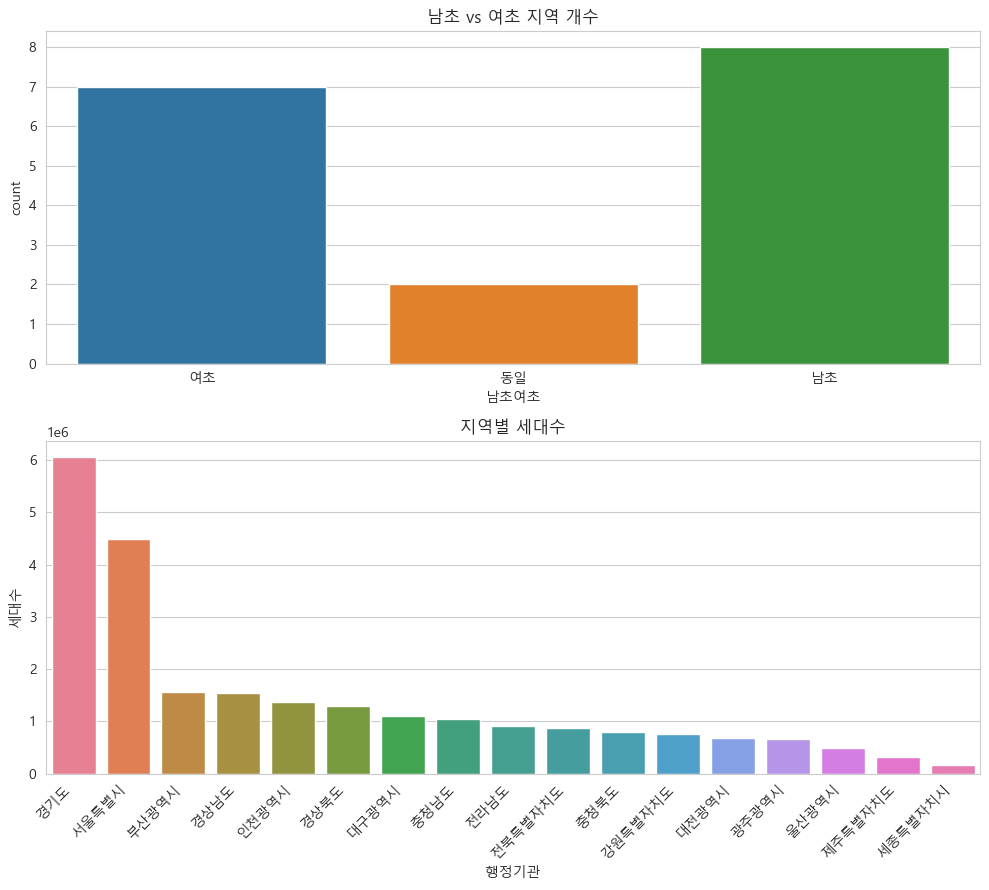

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 9))

# 남초 vs 여초 지역 개수
sns.countplot(data=df_region, x='남초여초', order=['여초', '동일', '남초'],
              hue='남초여초', legend=False, ax=axes[0])
axes[0].set_title('남초 vs 여초 지역 개수')
axes[0].set_xlabel('남초여초')
axes[0].set_ylabel('count')

# 지역별 세대수
df_house_count_sorted = df_region.sort_values(by='세대수', ascending=False)
sns.barplot(data=df_house_count_sorted, x='행정기관', y='세대수',
            hue='행정기관', palette='husl', legend=False, ax=axes[1])
axes[1].set_title('지역별 세대수')
axes[1].set_xlabel('행정기관')
axes[1].set_ylabel('세대수')
axes[1].tick_params(axis='x', rotation=45)
for label in axes[1].get_xticklabels():
    label.set_ha('right')

plt.tight_layout()
plt.show()